In [1]:
import os
import time
import torch
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import random

from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
import torchvision.transforms.functional as TF
from torch.utils.data import random_split

import albumentations as A
from albumentations.pytorch import ToTensorV2
# jonathan hint: bei genug bild daten anderes vortrainiertes model vorschieben
#profiling einbauen um bottleneck zu finden
Image.MAX_IMAGE_PIXELS = None
class SegmentationDataset(Dataset):
    def __init__(self, img_dir, mask_dir, patch_size=512, overlap=0.5, transform=None):
        self.img_paths = sorted([os.path.join(img_dir, f) for f in os.listdir(img_dir) if f.lower().endswith('.jpg')])
        self.mask_paths = sorted([os.path.join(mask_dir, f) for f in os.listdir(mask_dir) if f.lower().endswith('.png')])
        self.patch_size = patch_size
        self.step = int(patch_size * (1 - overlap))
        self.transform = transform
        self.patches = self._extract_patches()

    def _extract_patches(self):
        patches = []
        for img_path, mask_path in zip(self.img_paths, self.mask_paths):
            img = Image.open(img_path)
            width, height = img.size
            width = int(width / 2)
            height = int(height /2)
            img = img.resize((width, height), Image.Resampling.LANCZOS)
            mask = Image.open(mask_path).convert('L')
            mask = mask.resize((width, height), Image.Resampling.LANCZOS)
            w, h = img.size
            for y in range(0, h - self.patch_size + 1, self.step):
                for x in range(0, w - self.patch_size + 1, self.step):
                    patches.append((img_path, mask_path, x, y))
        return patches

    def __len__(self):
        return len(self.patches)

    def __getitem__(self, idx):
        img_path, mask_path, x, y = self.patches[idx]
        img = Image.open(img_path).crop((x, y, x+self.patch_size, y+self.patch_size))
        mask = Image.open(mask_path).crop((x, y, x+self.patch_size, y+self.patch_size))
        if self.transform:
            img, mask = self.transform(img, mask)
        return img, mask


In [2]:
class ToTensorAndEncode:
    def __init__(self, class_values):
        self.class_values = class_values
        self.img_tf = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]
            )
        ])

    def __call__(self, data):
        img = data['image']
        mask = data['mask']

        img_t = self.img_tf(img)
        mask_np = np.array(mask, dtype=np.uint8)

        label_map = np.digitize(mask_np, self.class_values, right=True) - 1
        for idx, value in enumerate(self.class_values):
            label_map[mask_np == value] = idx

        return {
            'image': img_t,
            'mask': torch.from_numpy(label_map).long()
        }


In [3]:


class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=0.0):
        super().__init__()
        layers = [
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        ]
        if dropout > 0:
            layers.insert(3, nn.Dropout2d(dropout))  # nach der ersten ReLU
        self.conv = nn.Sequential(*layers)

    def forward(self, x):
        return self.conv(x)
# dropout implementieren
class UNet(nn.Module):
    def __init__(self, n_classes, base_c=64, dropout=0.3):
        super().__init__()
        # Encoder
        self.down1 = DoubleConv(3, base_c)
        self.pool1 = nn.MaxPool2d(2)
        self.down2 = DoubleConv(base_c, base_c*2)
        self.pool2 = nn.MaxPool2d(2)
        self.down3 = DoubleConv(base_c*2, base_c*4, dropout=dropout)
        self.pool3 = nn.MaxPool2d(2)
        self.down4 = DoubleConv(base_c*4, base_c*8, dropout=dropout)
        self.pool4 = nn.MaxPool2d(2)
        # Bottleneck
        self.bottleneck = DoubleConv(base_c*8, base_c*16, dropout=dropout)
        # Decoder (kann optional auch Dropout bekommen)
        self.up4 = nn.ConvTranspose2d(base_c*16, base_c*8, kernel_size=2, stride=2)
        self.dec4 = DoubleConv(base_c*16, base_c*8)
        self.up3 = nn.ConvTranspose2d(base_c*8, base_c*4, kernel_size=2, stride=2)
        self.dec3 = DoubleConv(base_c*8, base_c*4)
        self.up2 = nn.ConvTranspose2d(base_c*4, base_c*2, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(base_c*4, base_c*2)
        self.up1 = nn.ConvTranspose2d(base_c*2, base_c, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(base_c*2, base_c)
        # Output
        self.outc = nn.Conv2d(base_c, n_classes, kernel_size=1)

    def forward(self, x):
        d1 = self.down1(x)
        p1 = self.pool1(d1)
        d2 = self.down2(p1)
        p2 = self.pool2(d2)
        d3 = self.down3(p2)
        p3 = self.pool3(d3)
        d4 = self.down4(p3)
        p4 = self.pool4(d4)

        bn = self.bottleneck(p4)

        u4 = self.up4(bn)
        c4 = self.dec4(torch.cat([u4, d4], dim=1))
        u3 = self.up3(c4)
        c3 = self.dec3(torch.cat([u3, d3], dim=1))
        u2 = self.up2(c3)
        c2 = self.dec2(torch.cat([u2, d2], dim=1))
        u1 = self.up1(c2)
        c1 = self.dec1(torch.cat([u1, d1], dim=1))

        return self.outc(c1)

In [4]:
class AugmentedDataset(Dataset):
    def __init__(self, img_dir, mask_dir, patch_size=512, overlap=0.5, transform=None):
        self.img_paths = sorted([
            os.path.join(img_dir, f) for f in os.listdir(img_dir) if f.lower().endswith('.jpg')
        ])
        self.mask_paths = sorted([
            os.path.join(mask_dir, f) for f in os.listdir(mask_dir) if f.lower().endswith('.png')
        ])
        self.patch_size = patch_size
        self.step = int(patch_size * (1 - overlap))
        self.transform = transform

        # 🔄 Define augmentations BEFORE extracting patches
        self.augmentations = [
            A.NoOp(),
            A.Rotate(limit=(90, 90), p=1),
            A.Rotate(limit=(180, 180), p=1),
            A.Rotate(limit=(270, 270), p=1),
            A.HorizontalFlip(p=1),
            A.VerticalFlip(p=1),
            A.Compose([
                A.HorizontalFlip(p=1),
                A.VerticalFlip(p=1)
            ]),
            A.Compose([
                A.Rotate(limit=(90, 90), p=1),
                A.HorizontalFlip(p=1)
            ]),
            A.ColorJitter(brightness=0.4, contrast=0.0, saturation=0.0, hue=0.0, p=1),
            A.ColorJitter(brightness=0.0, contrast=0.4, saturation=0.0, hue=0.0, p=1),
            A.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.0, hue=0.0, p=1),
        ]
        self.patches = self._extract_patches()


    def _extract_patches(self):
        patches = []
        for img_path, mask_path in zip(self.img_paths, self.mask_paths):
            img = Image.open(img_path)
            mask = Image.open(mask_path).convert('L')

            # Resize
            width, height = img.size
            new_size = (width // 2, height // 2)
            img = img.resize(new_size, Image.Resampling.LANCZOS)
            mask = mask.resize(new_size, Image.Resampling.LANCZOS)

            # Crop to patches
            w, h = new_size
            for y in range(0, h - self.patch_size + 1, self.step):
                for x in range(0, w - self.patch_size + 1, self.step):
                    img_patch = img.crop((x, y, x + self.patch_size, y + self.patch_size))
                    mask_patch = mask.crop((x, y, x + self.patch_size, y + self.patch_size))
                    for aug_type in range(len(self.augmentations)):
                        patches.append((img_patch.copy(), mask_patch.copy(), aug_type))
        return patches

    def __len__(self):
        return len(self.patches)

    def __getitem__(self, idx):
        img, mask, aug_type = self.patches[idx]

        # Convert PIL to numpy
        img_np = np.array(img)
        mask_np = np.array(mask)

        # Apply Albumentations
        augmented = self.augmentations[aug_type](image=img_np, mask=mask_np)
        if self.transform:
            transformed = self.transform(augmented)
            img_np, mask_np = transformed['image'], transformed['mask']
        else:
            img_np, mask_np = augmented['image'], augmented['mask']

        return img_np, mask_np

In [5]:
def get_num_classes(mask_dir):
    unique_values = set()
    for filename in tqdm(os.listdir(mask_dir)):
        if filename.endswith(".png"):
            mask = np.array(Image.open(os.path.join(mask_dir, filename)).convert('L'))
            unique_values.update(np.unique(mask))
    return len(unique_values), unique_values
mask_path = 'images/masks'
#n_classes, class_values = get_num_classes(mask_path)
n_classes = 3
class_values = [0, 150, 255]
print(f"Detected {n_classes} unique classes: {class_values}")

Detected 3 unique classes: [0, 150, 255]


In [6]:
if __name__ == "__main__":
    # Hyperparameter
    lr = 1e-4
    epochs = 30
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Dataset & DataLoader
    transform = ToTensorAndEncode(class_values=class_values)

    full_dataset = AugmentedDataset('images/imgs', 'images/masks', transform=transform)

    val_split = 0.2
    val_len = int(len(full_dataset) * val_split)
    train_len = len(full_dataset) - val_len

    # Split the dataset
    generator = torch.Generator().manual_seed(42)
    train_ds, val_ds = random_split(full_dataset, [train_len, val_len], generator=generator)

    # Create DataLoaders
    train_loader = DataLoader(train_ds, batch_size=8, shuffle=True, num_workers=0)
    val_loader   = DataLoader(val_ds,   batch_size=8, shuffle=False, num_workers=0)

    # Modell, Optimizer, Scheduler
    model = UNet(n_classes).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr) # AdamW , weight decay?
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)
    best_iou = 0.0

    def dice_coef(pred, target, eps=1e-6):
        # pred, target: one-hot [B, C, H, W]
        intersection = (pred * target).sum(dim=(2,3))
        union = pred.sum(dim=(2,3)) + target.sum(dim=(2,3))
        return ((2 * intersection + eps) / (union + eps)).mean()
    def compute_class_weights(train_loader, n_classes):
        class_counts = [0] * n_classes
        for imgs, masks in tqdm(train_loader, desc="Counting class frequencies"):
            _, labels = masks.max(dim=1)  # Get the class labels from the masks
            for i in range(n_classes):
                class_counts[i] += (labels == i).sum().item()
        
        total_pixels = sum(class_counts)
        class_weights = [total_pixels / count if count != 0 else 1 for count in class_counts]
        class_weights = torch.tensor(class_weights).float().to(device)
        return class_weights

    # Calculate class weights based on the training dataset
    #class_weights = compute_class_weights(train_loader, n_classes)
    class_weights = torch.tensor([1, 10, 100]).float().to(device)
    print(class_weights)

KeyboardInterrupt: 

In [ ]:

t0 = time.time()
checkpoint = 'best_unet.pth'
losses = []
val_losses = []
def weighted_cross_entropy_loss(logits, masks, class_weights):
    return F.cross_entropy(logits, masks, weight=class_weights)

if os.path.exists(checkpoint):
    print(f"Loading saved model from {checkpoint}")
    model.load_state_dict(torch.load(checkpoint))
    model.eval()
for epoch in range(epochs):
    model.train()
    train_loss = 0
    class_counts = [0] *n_classes
    for imgs, masks in tqdm(train_loader, desc=f"Train Ep {epoch}"):
        imgs, masks = imgs.to(device), masks.to(device)
        logits = model(imgs)
        loss = weighted_cross_entropy_loss(logits, masks, class_weights)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)
    losses.append(train_loss)
    # Validierung
    model.eval()
    val_loss, val_dice = 0, 0
    with torch.no_grad():
        for imgs, masks in tqdm(val_loader, desc=f"Val"):
            imgs, masks = imgs.to(device), masks.to(device)

            logits = model(imgs)

            preds = F.softmax(logits, dim=1)
            val_loss += F.cross_entropy(logits, masks, weight=class_weights).item()
            pred_classes = preds.argmax(dim=1)
            for i in range(n_classes):
                class_counts[i] += (pred_classes == i).sum().item()
            masks_one_hot = F.one_hot(masks, num_classes=n_classes).permute(0, 3, 1, 2).float()
            val_dice += dice_coef(preds, masks_one_hot).item()
    
    val_loss /= len(val_loader)
    val_losses.append(val_loss)
    val_dice /= len(val_loader)
    scheduler.step(val_loss)
    print(f"Epoch {epoch} — Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Dice: {val_dice:.4f}")
    print("Class Detection Counts (Train):")
    for i, count in enumerate(class_counts):
        print(f"Class {i}: {count} pixels detected")
    # Modell speichern
    if val_dice > best_iou:
        best_iou = val_dice
        torch.save(model.state_dict(), checkpoint)

Val: 100%|██████████| 1771/1771 [06:14<00:00,  4.73it/s]

Epoch 0 — Train Loss: 0.3597 | Val Loss: 0.2779 | Val Dice: 0.3179
Class Detection Counts (Train):
Class 0: 2816302840 pixels detected
Class 1: 0 pixels detected
Class 2: 897753352 pixels detected


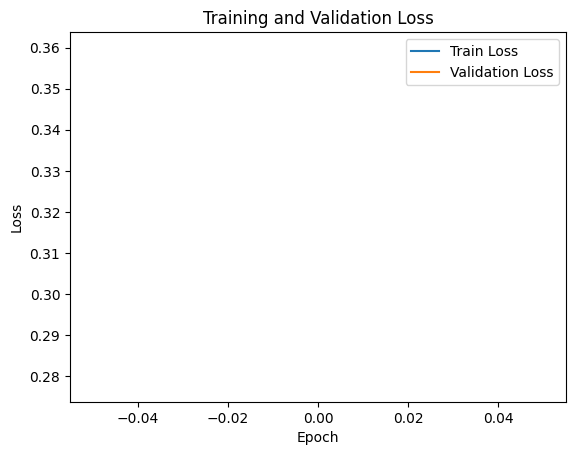

In [ ]:

plt.plot(range(epochs), losses, label='Train Loss')
plt.plot(range(epochs), val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

Loading saved model from best_unet.pth


  0%|          | 0/6 [00:00<?, ?it/s]

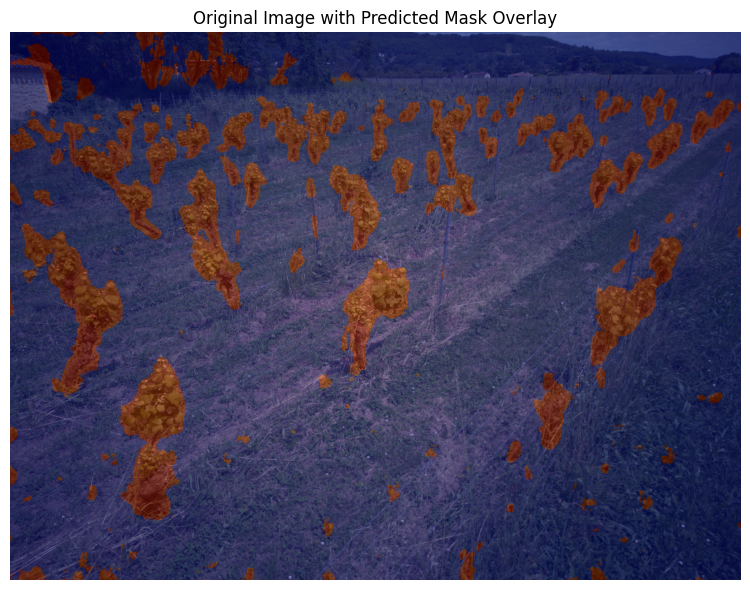

 17%|█▋        | 1/6 [02:24<12:02, 144.45s/it]

[  0 255]


FileNotFoundError: [Errno 2] No such file or directory: 'images/imgs/DJI_0561.jpg'

In [ ]:
checkpoint = 'best_unet.pth'
if os.path.exists(checkpoint):
    model = UNet(n_classes).to(device)
    print(f"Loading saved model from {checkpoint}")
    model.load_state_dict(torch.load(checkpoint))
    model.eval()
def predict_img(net,
                full_img,
                device,
                out_threshold=0.5,
                class_values=None):
    """
    Predict the segmentation mask for a full PIL image using the given model.

    Args:
        net           : Trained segmentation model
        full_img      : PIL.Image input image (RGB)
        device        : torch.device
        out_threshold : Threshold for binary segmentation (ignored if multi-class)
        class_values  : Optional list of grayscale values for classes (for decoding)

    Returns:
        Numpy array of the predicted mask (HxW) as integers
    """
    net.eval()

    tf = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std= [0.229, 0.224, 0.225])
    ])  # Keine Normalisierung mehr
    img_tensor = tf(full_img).unsqueeze(0).to(device=device, dtype=torch.float32)

    with torch.no_grad():
        output = net(img_tensor)
        output = F.interpolate(output, size=full_img.size[::-1], mode='bilinear', align_corners=False)

        probs = F.softmax(output, dim=1)
        pred = torch.argmax(probs, dim=1).squeeze(0).cpu().numpy()

        if class_values:
            pred_mask = np.zeros_like(pred, dtype=np.uint8)
            for idx, val in enumerate(class_values):
                pred_mask[pred == idx] = val
        else:
            pred_mask = pred.astype(np.uint8)

    # Plotten des Vorhersage-Masks
    plt.figure(figsize=(8, 6))
    plt.imshow(full_img)  # Original image
    plt.imshow(pred_mask, cmap='jet', alpha=0.5)  # Semi-transparent mask overlay
    plt.title("Original Image with Predicted Mask Overlay")
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    return pred_mask




    return pred_mask
for i in tqdm(os.listdir("testdaten")):
    path ="testdaten" + i
    img = Image.open(path).convert("RGB")
    width, height = img.size
    width = int(width / 2)
    height = int(height /2)
    img = img.resize((width, height), Image.Resampling.LANCZOS)
    pred_mask = predict_img(
        net=model,
        full_img=img,
        device=torch.device("cuda" if torch.cuda.is_available() else "cpu"),
        class_values=[0, 150, 255]  # optional, if your classes use specific grayscale values
    )
    out_path="some_image_mask.jpg"
    print(np.unique(pred_mask))
"""mask_img = Image.fromarray(pred_mask)
if pred_mask.ndim == 2:
    mask_img = mask_img.convert('L')
else:
    mask_img = mask_img.convert('RGB')

mask_img.save(out_path)"""